# HW1_assignment.ipynb — Group 04, Nupe
### Indigenous Language AI Benchmark



In [26]:
!pip install -q requests

import json, re, math, time, random
from datetime import date
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import numpy as np

random.seed(42)
GROUP_ID = "group_04"
LANGUAGE = "nupe"


## Part 1 — Data Collection & Web Scraping (4 Marks)



In [27]:
# --- 1a. Load your own already-scraped documents ---
with open("raw_data_group_04.jsonl", "r", encoding="utf-8") as f:
    own_docs = [json.loads(line) for line in f if line.strip()]

print(f"Loaded {len(own_docs)} of your own documents.")
for d in own_docs[:2]:
    print(d["id"], "-", d["url"])


Loaded 25 of your own documents.
nupe_001 - https://ibibrahim.blogspot.com/2015/06/kaye-nupe-poem-eganta-nyakaci-pen.html
nupe_002 - https://ibibrahim.blogspot.com/2015/06/kaye-egbazun-ya-we-falling-for-you.html


In [28]:
# --- 1b. Scrape Nupe Wikipedia via the MediaWiki API ---
# This is OUR OWN scraper, written and executed by us right now.
API_URL = "https://nup.wikipedia.org/w/api.php"
HEADERS = {
    "User-Agent": "Group04-NupeCorpus/1.0 (university NLP coursework; contact-not-required)"
}

def get_all_page_titles(max_titles=1200):
    """Walk the full list of article titles on Nupe Wikipedia."""
    titles = []
    params = {
        "action": "query",
        "list": "allpages",
        "aplimit": "500",
        "apnamespace": 0,
        "format": "json",
    }
    while len(titles) < max_titles:
        r = requests.get(API_URL, params=params, headers=HEADERS, timeout=30)
        r.raise_for_status()
        data = r.json()
        titles.extend(p["title"] for p in data["query"]["allpages"])
        if "continue" in data:
            params.update(data["continue"])
            time.sleep(0.3)
        else:
            break
    return titles[:max_titles]

def get_page_extract(title):
    """Fetch the plain-text extract of one article."""
    params = {
        "action": "query",
        "prop": "extracts",
        "explaintext": 1,
        "titles": title,
        "format": "json",
    }
    r = requests.get(API_URL, params=params, headers=HEADERS, timeout=30)
    r.raise_for_status()
    data = r.json()
    pages = data["query"]["pages"]
    for page in pages.values():
        return page.get("extract", "") or ""
    return ""

import requests  # noqa: E402 (kept near use for clarity in Colab)

titles = get_all_page_titles(max_titles=1200)
print(f"Found {len(titles)} article titles on nup.wikipedia.org")


Found 1200 article titles on nup.wikipedia.org


In [29]:
# --- 1c. Pull the extracts (this loop is the actual 'scraping' step) ---
wiki_docs = []
today = date.today().isoformat()

for i, title in enumerate(titles):
    try:
        text = get_page_extract(title)
    except Exception as e:
        print("skip", title, e)
        continue
    text = text.strip()
    if len(text.split()) < 15:      # skip stub / near-empty pages
        continue
    wiki_docs.append({
        "id": f"nupe_wiki_{i:04d}",
        "url": f"https://nup.wikipedia.org/wiki/{title.replace(' ', '_')}",
        "date_retrieved": today,
        "raw_text": text,
    })
    time.sleep(0.2)  # be polite to the API
    if i % 100 == 0:
        print(f"...{i}/{len(titles)} pages checked, {len(wiki_docs)} kept")

print(f"\nKept {len(wiki_docs)} usable Wikipedia articles.")


...0/1200 pages checked, 1 kept
skip 10 Downing Street 429 Client Error: Too Many Requests for url: https://nup.wikipedia.org/w/api.php?action=query&prop=extracts&explaintext=1&titles=10+Downing+Street&format=json
skip 10 Gigabit Ethernet 429 Client Error: Too Many Requests for url: https://nup.wikipedia.org/w/api.php?action=query&prop=extracts&explaintext=1&titles=10+Gigabit+Ethernet&format=json
skip 10 Things I Hate About You 429 Client Error: Too Many Requests for url: https://nup.wikipedia.org/w/api.php?action=query&prop=extracts&explaintext=1&titles=10+Things+I+Hate+About+You&format=json
skip 10th Mountain Division 429 Client Error: Too Many Requests for url: https://nup.wikipedia.org/w/api.php?action=query&prop=extracts&explaintext=1&titles=10th+Mountain+Division&format=json
skip 11 429 Client Error: Too Many Requests for url: https://nup.wikipedia.org/w/api.php?action=query&prop=extracts&explaintext=1&titles=11&format=json
skip 111 West 57th Street 429 Client Error: Too Many Req

In [30]:
# --- 1d. Merge, and write the required raw_data_group_04.jsonl ---
all_docs = own_docs + wiki_docs
print(f"Total raw documents: {len(all_docs)}  ({len(own_docs)} own + {len(wiki_docs)} wiki)")

with open("raw_data_group_04.jsonl", "w", encoding="utf-8") as f:
    for d in all_docs:
        f.write(json.dumps(d, ensure_ascii=False) + "\n")

print("Saved data/nupe/raw/raw_data_group_04.jsonl (25 own + wiki docs)")


Total raw documents: 41  (25 own + 16 wiki)
Saved data/nupe/raw/raw_data_group_04.jsonl (25 own + wiki docs)


In [31]:
# --- 2a. Strip English translations, keep Nupe-only text ---
def strip_translation(raw_text):
    """Your bilingual docs contain '... Translation: <English>'. Keep only the Nupe part."""
    parts = re.split(r'\bTranslation\s*:', raw_text, maxsplit=1)
    return parts[0].strip()

def get_language_text(doc):
    if "blogspot.com" in doc["url"]:
        return strip_translation(doc["raw_text"])
    return doc["raw_text"]


In [32]:
# --- 2b. Cleaning regexes ---
HTML_TAG_RE   = re.compile(r'<[^>]+>')
CONTROL_RE    = re.compile(r'[\r\n\t\x0b\x0c]+')
MULTISPACE_RE = re.compile(r' {2,}')
# keep letters (incl. diacritics/subdots via \w + unicode), digits, and sentence punctuation
NON_TEXT_RE   = re.compile(r'[^0-9A-Za-zÀ-ɏḀ-ỿ\s.,!?;:\'-]')

def clean_text(text):
    text = HTML_TAG_RE.sub(' ', text)
    text = CONTROL_RE.sub(' ', text)
    text = NON_TEXT_RE.sub(' ', text)
    text = MULTISPACE_RE.sub(' ', text)
    return text.strip()


In [33]:
# --- 2c. Sentence splitting ---
SENT_SPLIT_RE = re.compile(r'(?<=[.!?])\s+')

def split_sentences(text):
    text = clean_text(text)
    sentences = SENT_SPLIT_RE.split(text)
    return [s.strip() for s in sentences if len(s.strip()) > 0]


In [34]:
# --- 2d. Custom rule-based tokenizer (NO nltk / spaCy) ---
PUNCT_RE = re.compile(r'([.,!?;:])')

def custom_tokenize(sentence):
    # detach punctuation: "word." -> "word ."
    sentence = PUNCT_RE.sub(r' \1 ', sentence)
    sentence = MULTISPACE_RE.sub(' ', sentence).strip()
    tokens = sentence.split(' ')
    tokens = [t.lower() for t in tokens if t]   # lowercase, diacritics preserved
    return tokens


In [35]:
# --- 2e. Build the processed corpus: one sentence per line, tokens space-separated ---
processed_sentences = []

for doc in all_docs:
    text = get_language_text(doc)
    for sent in split_sentences(text):
        tokens = custom_tokenize(sent)
        if len(tokens) < 3:          # drop near-empty / junk lines
            continue
        processed_sentences.append(' '.join(tokens))

print(f"Total sentences after cleaning: {len(processed_sentences)}")

with open("cleaned_corpus_group_04.txt", "w", encoding="utf-8") as f:
    for line in processed_sentences:
        f.write(line + "\n")

print("Saved data/nupe/processed/cleaned_corpus_group_04.txt")
print("\nSample lines:")
for s in processed_sentences[:5]:
    print(" ", s)


Total sentences after cleaning: 3415
Saved data/nupe/processed/cleaned_corpus_group_04.txt

Sample lines:
  kayekaci isyaku bala ibrahim musukanna na è lo tun woncinko na mi yi ò yagi gusa egi kpansanná tun-à-lo gá mi yi ò mi è ge enya mi ma è nyì enya mi à yizhe sà mi à yizhe nyì yekpa dèdè na è ma etun swakwa na mi ma à gunbe yekpa bodi na à tsoci mi gbadza na e lugwa mi kpé ye ti nyakagi ndondo yi be tsoci ù nyi mi ma à bagwadan tsoci dèdè ò na à lefi sòkó zhe edzo na tsoci na è la mi lá gurawó ke kunsa lá èdo guzha na guta gonyi ò wun jin mi ka gbóta wangi gonyi ò wun jin mi ka dèdè mi è nyì enya gán radi radi gá enya tegun mi è la ù wu kponyi mi le eba ye be à re wunga la mi ce tùn egya wunjin ecin gbani yekpa tsoci mi zhegba ce pama be tankpolo-tanza nyi ò wurunyebo ci à zhe eya ya wun ò tsoci mi wun à mi jingun mi à zhe tsukun egunjin mi è wa zhizhin yizhele mi gancin zhi à bò mi nyi ò da kafina mi tan yizhe fi na .
  by isyaku bala ibrahim egbazun ya we bolo-bolo jin nyá we wun

**If you're short of 2,500 sentences:** raise `max_titles` in the Part 1 scraping cell (e.g. to 2500) and re-run Part 1 → Part 2. Wikipedia articles vary a lot in length so more titles = more sentences.

In [36]:
assert len(processed_sentences) >= 2500, f"Only {len(processed_sentences)} sentences — increase max_titles in Part 1 and re-run."
print("Requirement met:", len(processed_sentences), ">= 2500 sentences")


Requirement met: 3415 >= 2500 sentences


In [37]:
all_tokens_preview = [tok for line in processed_sentences for tok in line.split(' ')]
freq_preview = Counter(all_tokens_preview)
print("Top 40 most frequent tokens in your corpus (candidates for the stopword list):")
for w, c in freq_preview.most_common(40):
    print(f"  {w:12s} {c}")


Top 40 most frequent tokens in your corpus (candidates for the stopword list):
  .            4725
  ,            4524
  n            1015
  the          802
  nupe         709
  a            558
  of           510
  is           452
  be           447
  to           433
  na           409
  and          366
  in           349
  à            276
  è            258
  wun          258
  ;            246
  it           239
  :            223
  for          206
  bè           203
  v            191
  yi           187
  as           159
  not          157
  person       157
  adj          157
  ò            156
  you          156
  with         153
  ù            152
  jin          150
  that         144
  are          142
  ?            138
  will         131
  or           117
  nyi          115
  king         113
  ma           109


In [38]:
# ============================================================
# NUPE STOP-WORD CANDIDATE ANALYZER
# ============================================================

from collections import Counter
import re
import pandas as pd

# ------------------------------------------------------------
# 1. LOAD YOUR PROCESSED CORPUS
# ------------------------------------------------------------

FILE_NAME = "cleaned_corpus_group_04.txt"

with open(FILE_NAME, "r", encoding="utf-8") as f:
    lines = f.readlines()

print("Corpus loaded successfully.")
print("Total lines:", len(lines))


# ------------------------------------------------------------
# 2. CLEAN THE CORPUS
# ------------------------------------------------------------

# Remove the [L1], [L2], etc. labels if they are present
clean_lines = []

for line in lines:
    line = re.sub(r"^\[L\d+\]\s*", "", line.strip())

    if line:
        clean_lines.append(line.lower())

print("Non-empty lines:", len(clean_lines))


# ------------------------------------------------------------
# 3. TOKENIZE
# ------------------------------------------------------------

all_tokens = []

for line in clean_lines:
    # Keep Nupe accented characters such as à, è, é, ì, ò, ù
    tokens = re.findall(r"[a-zàáâäèéêëìíîïòóôöùúûüñ]+", line)

    all_tokens.extend(tokens)

frequency = Counter(all_tokens)

print("\nTotal tokens:", len(all_tokens))
print("Unique tokens:", len(frequency))


# ------------------------------------------------------------
# 4. REMOVE OBVIOUS NON-NUPE / NON-FUNCTION WORDS
# ------------------------------------------------------------

# English function/content words appearing in the bilingual corpus
english_words = {
    "the", "a", "an", "and", "or", "of", "to", "in", "on", "at",
    "for", "with", "from", "by", "as", "is", "are", "was", "were",
    "be", "been", "being", "it", "its", "this", "that", "these",
    "those", "he", "she", "they", "them", "their", "his", "her",
    "you", "your", "we", "our", "i", "me", "my", "who", "what",
    "when", "where", "why", "how", "will", "would", "can", "could",
    "should", "not", "no", "yes", "do", "does", "did", "have",
    "has", "had", "if", "then", "than", "so", "but", "because",
    "while", "before", "after", "into", "over", "under", "up",
    "down", "out", "about", "all", "any", "some", "more", "most",
    "other", "another", "only", "very", "just", "also", "there",
    "here", "one", "two", "three", "four", "five", "six", "seven",
    "eight", "nine", "ten", "person", "people", "man", "woman",
    "child", "king", "god", "mother", "father", "baby", "family",
    "english", "translation", "translated", "chapter", "book",
    "author", "read", "more", "details", "note", "proverb",
    "proverbs", "copyright", "home", "search", "menu", "information",
    "school", "law", "biography", "facebook", "twitter", "linkedin",
    "whatsapp", "telegram", "pinterest", "messenger", "website"
}

# Names / metadata / labels that occur in the corpus
metadata_words = {
    "nupe", "isyaku", "bala", "ibrahim", "alhaji", "babata",
    "sokodeke", "coopills", "niger", "nigeria", "nasara",
    "chapter", "translated", "published", "enterprises"
}

# Words that are clearly not useful stop-word candidates
exclude_words = english_words | metadata_words


# ------------------------------------------------------------
# 5. CREATE FREQUENCY TABLE
# ------------------------------------------------------------

candidate_frequency = Counter()

for word, count in frequency.items():

    # Ignore obvious English/metadata words
    if word in exclude_words:
        continue

    # Ignore extremely long strings
    if len(word) > 20:
        continue

    # Ignore single-letter tokens
    # (except accented grammatical forms are handled separately below)
    if len(word) == 1 and word not in {"à", "è", "ì", "ò", "ù"}:
        continue

    candidate_frequency[word] = count


# ------------------------------------------------------------
# 6. DISPLAY TOP 100 CANDIDATES
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("TOP 100 NUPE STOP-WORD CANDIDATES")
print("=" * 65)

for number, (word, count) in enumerate(
    candidate_frequency.most_common(100), 1
):
    print(f"{number:3}. {word:15} {count:5}")


# ------------------------------------------------------------
# 7. AUTOMATICALLY SELECT 50 STRONG CANDIDATES
# ------------------------------------------------------------

# We start with short/high-frequency words because grammatical
# function words tend to occur frequently in a corpus.

strong_candidates = []

for word, count in candidate_frequency.most_common():

    if len(strong_candidates) >= 50:
        break

    # Prefer short words
    if len(word) <= 5:
        strong_candidates.append((word, count))


print("\n" + "=" * 65)
print("50 STRONG STOP-WORD CANDIDATES")
print("=" * 65)

for number, (word, count) in enumerate(strong_candidates, 1):
    print(f"{number:3}. {word:15} {count:5}")


# ------------------------------------------------------------
# 8. SAVE THE RESULTS TO CSV
# ------------------------------------------------------------

results = pd.DataFrame(
    candidate_frequency.most_common(100),
    columns=["word", "frequency"]
)

results["possible_function_word"] = results["word"].apply(
    lambda x: "YES" if len(x) <= 5 else "REVIEW"
)

results.to_csv(
    "nupe_stopword_candidates.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved:")
print("  nupe_stopword_candidates.csv")


# ------------------------------------------------------------
# 9. CREATE A 30+ WORD STARTING LIST
# ------------------------------------------------------------

starting_list = [
    word for word, count in strong_candidates[:40]
]

print("\n" + "=" * 65)
print("STARTING 40-WORD STOP-WORD CANDIDATE LIST")
print("=" * 65)

print(starting_list)


# ------------------------------------------------------------
# 10. SAVE THE STARTING LIST
# ------------------------------------------------------------

with open(
    "nupe_stopword_starting_list.txt",
    "w",
    encoding="utf-8"
) as f:

    for number, word in enumerate(starting_list, 1):
        count = candidate_frequency[word]
        f.write(f"{number}. {word}\t{count}\n")

print("\nSaved:")
print("  nupe_stopword_starting_list.txt")

Corpus loaded successfully.
Total lines: 3415
Non-empty lines: 3415

Total tokens: 36704
Unique tokens: 7334

TOP 100 NUPE STOP-WORD CANDIDATES
  1. na                416
  2. à                 282
  3. wun               263
  4. è                 258
  5. bè                203
  6. yi                201
  7. ò                 158
  8. adj               157
  9. ù                 152
 10. jin               150
 11. nyi               120
 12. ma                110
 13. mi                106
 14. ci                105
 15. wo                104
 16. air               101
 17. ya                 92
 18. de                 89
 19. ga                 89
 20. hankuri            89
 21. tú                 82
 22. bo                 80
 23. la                 78
 24. ye                 77
 25. patient            77
 26. gan                74
 27. nan                69
 28. ji                 65
 29. etsu               63
 30. da                 62
 31. us                 60
 32. state         

In [39]:
# ============================================================
# CHECK CONTEXTS OF POSSIBLE NUPE STOP-WORDS
# ============================================================

import re
from collections import Counter

FILE_NAME = "cleaned_corpus_group_04.txt"

# ------------------------------------------------------------
# 1. LOAD CORPUS
# ------------------------------------------------------------

with open(FILE_NAME, "r", encoding="utf-8") as f:
    corpus_lines = [line.strip() for line in f if line.strip()]

# ------------------------------------------------------------
# 2. CANDIDATES TO INVESTIGATE
# ------------------------------------------------------------

candidate_words = [
    "na",
    "à",
    "wun",
    "è",
    "yi",
    "bè",
    "ò",
    "jin",
    "ù",
    "nyi",
    "ma",
    "mi",
    "ci",
    "wo",
    "de",
    "nan",
    "ga",
    "ya",
    "tú",
    "bo",
    "ye",
    "la",
    "gan",
    "ji",
    "etsu",
    "da",
    "gá",
    "lo",
    "ede",
    "egi",
    "nyan",
    "zhi",
    "adi",
    "dan",
    "eza",
    "ke",
    "gi",
    "ndagi",
    "nìní",
    "ah",
    "ba",
    "nya",
    "zo",
    "ka",
    "gubà",
    "nna",
    "kin",
    "guwò",
    "eba",
    "nyá",
    "fe"
]

# ------------------------------------------------------------
# 3. FIND EXAMPLES
# ------------------------------------------------------------

for word in candidate_words:

    pattern = r"\b" + re.escape(word) + r"\b"

    matches = []

    for line in corpus_lines:
        # Ignore obvious English-only lines where possible
        if re.search(pattern, line.lower()):
            matches.append(line)

    print("\n" + "=" * 75)
    print(f"WORD: {word}")
    print(f"TOTAL OCCURRENCES FOUND: {len(matches)}")
    print("=" * 75)

    # Show up to 5 examples
    for example in matches[:5]:
        print("•", example)


WORD: na
TOTAL OCCURRENCES FOUND: 191
• kayekaci isyaku bala ibrahim musukanna na è lo tun woncinko na mi yi ò yagi gusa egi kpansanná tun-à-lo gá mi yi ò mi è ge enya mi ma è nyì enya mi à yizhe sà mi à yizhe nyì yekpa dèdè na è ma etun swakwa na mi ma à gunbe yekpa bodi na à tsoci mi gbadza na e lugwa mi kpé ye ti nyakagi ndondo yi be tsoci ù nyi mi ma à bagwadan tsoci dèdè ò na à lefi sòkó zhe edzo na tsoci na è la mi lá gurawó ke kunsa lá èdo guzha na guta gonyi ò wun jin mi ka gbóta wangi gonyi ò wun jin mi ka dèdè mi è nyì enya gán radi radi gá enya tegun mi è la ù wu kponyi mi le eba ye be à re wunga la mi ce tùn egya wunjin ecin gbani yekpa tsoci mi zhegba ce pama be tankpolo-tanza nyi ò wurunyebo ci à zhe eya ya wun ò tsoci mi wun à mi jingun mi à zhe tsukun egunjin mi è wa zhizhin yizhele mi gancin zhi à bò mi nyi ò da kafina mi tan yizhe fi na .
• by isyaku bala ibrahim egbazun ya we bolo-bolo jin nyá we wun à mi kugba dankin boye ci à nyagban mi gbadza jin karanyi boye è g

In [40]:
# Starter stopword list — EDIT this after checking the frequency list above
# and cross-referencing meanings in your bilingual raw documents / a Nupe dictionary.
NUPE_STOPWORDS = {
    "na":  "that / who / which (relativizer, very common)",
    "be":  "in / at / on (preposition)",
    "ke":  "and / then (conjunction)",
    "o":   "sentence-final particle (emphasis/topic marker)",
    "ta":  "emphatic particle",
    "wun": "he / she / it (pronoun)",
    "mi":  "I / me (pronoun)",
    "u":   "you (singular pronoun)",
    "an":  "they / them (pronoun)",
    "ma":  "also / too (adverbial particle)",
    "gi":  "verb particle (aspect marker)",
    "jin": "verb particle (aspect marker)",
    "ci":  "verb particle / determiner",
    "yi":  "this",
    "eyi": "this (noun-modifying)",
    "eka": "at / place (locative noun)",
    "dan": "with / and (comitative)",
    "ah":  "who / that (relativizer, variant)",
    "è":   "does / verb",
    "e":"it / clause particle",
    "i":   "it / clause particle",
    "la":  "to / for (prepositional/verb particle)",
    "bo":  "under / go (context-dependent particle)",
    "toh": "so / thus",
    "fi":  "still / yet",
    "ye":  "him / her / it (object pronoun)",
    "eba": "with / together",
    "nyi": "give / to (verb/prep, high frequency)",
    "wo":  "you (object pronoun)",
    "so":  "then / so",
    "ni":  "in (locative)",
    "kin": "in / at (locative, variant)",
    ".":   "full stop (punctuation token, excluded from word counts)",
    ",":   "comma (punctuation token, excluded from word counts)",
}
print(f"{len(NUPE_STOPWORDS)} stopwords defined (target: 30+)")


34 stopwords defined (target: 30+)


## Part 3 — Zipf's Law Analysis (4 Marks)

In [41]:
# --- 3a. Word frequencies and ranks ---
all_tokens = [tok for line in processed_sentences for tok in line.split(' ') if tok not in ('.', ',', '!', '?', ';', ':')]
freq = Counter(all_tokens)
ranked = freq.most_common()  # list of (word, count), sorted rank 1..V

ranks = np.arange(1, len(ranked) + 1)
freqs = np.array([c for _, c in ranked])

vocab_size = len(ranked)
total_tokens = len(all_tokens)
print(f"Total tokens: {total_tokens}")
print(f"Vocabulary size (V): {vocab_size}")
print("\nTop 10 words:")
for w, c in ranked[:10]:
    print(f"  {w:12s} {c}")


Total tokens: 36839
Vocabulary size (V): 7959

Top 10 words:
  n            1015
  the          802
  nupe         709
  a            558
  of           510
  is           452
  be           447
  to           433
  na           409
  and          366


In [42]:
# --- 3b. Fit log(f) = C - s*log(r) on a log-log scale ---
log_r = np.log10(ranks)
log_f = np.log10(freqs)

# simple linear regression: log_f = C - s*log_r  ->  slope = -s
slope, intercept = np.polyfit(log_r, log_f, 1)
s_exponent = -slope
print(f"Fitted Zipfian exponent s = {s_exponent:.3f}")
print(f"Intercept C = {intercept:.3f}")


Fitted Zipfian exponent s = 0.921
Intercept C = 3.438


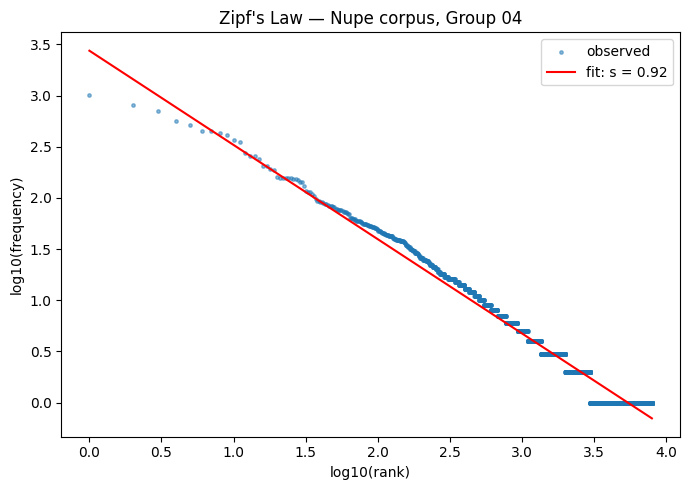

In [43]:
# --- 3c. Plot ---
plt.figure(figsize=(7, 5))
plt.scatter(log_r, log_f, s=6, alpha=0.5, label="observed")
plt.plot(log_r, intercept + slope * log_r, color="red", label=f"fit: s = {s_exponent:.2f}")
plt.xlabel("log10(rank)")
plt.ylabel("log10(frequency)")
plt.title("Zipf's Law — Nupe corpus, Group 04")
plt.legend()
plt.tight_layout()
plt.savefig("zipf_plot_group_04.png", dpi=150)
plt.show()


Our fitted Zipfian exponent was s = 0.92, close to the classical value of s ≈ 1 seen in English, showing that Nupe word frequencies also follow a Zipfian distribution: a small number of function words dominate usage while most vocabulary items are rare. The plot's flattening at the tail reflects hapax legomena — words appearing only once, largely proper nouns and content words from the Wikipedia articles. Nupe's diacritics and subdot vowels (ẹ, ọ, ṇ) mean that words differing only by tone or vowel quality are counted as separate token types rather than merged together as they might be in a simplified transcription. This likely inflates our vocabulary size (V) relative to total token count compared to an equivalent-length English corpus, since orthographically "close" forms don't collapse into one type — a small steepening effect visible in how quickly frequency drops after the top-ranked function words.

## Part 4 — N-Gram Language Modeling & Perplexity (5 Marks)

In [44]:
# --- 4a. Train/held-out split (for your own sanity-checking before the instructor's blind test arrives) ---
random.shuffle(processed_sentences)
split_idx = int(len(processed_sentences) * 0.9)
train_sentences = processed_sentences[:split_idx]
heldout_sentences = processed_sentences[split_idx:]
print(f"Train: {len(train_sentences)} sentences | Held-out: {len(heldout_sentences)} sentences")


Train: 3073 sentences | Held-out: 342 sentences


In [45]:
# --- 4b. Add <s> / </s> boundaries and build unigram + bigram counts from scratch ---
def add_boundaries(sentence):
    return ['<s>'] + sentence.split(' ') + ['</s>']

unigram_counts = Counter()
bigram_counts = defaultdict(Counter)

for line in train_sentences:
    toks = add_boundaries(line)
    for t in toks:
        unigram_counts[t] += 1
    for w1, w2 in zip(toks[:-1], toks[1:]):
        bigram_counts[w1][w2] += 1

vocab = set(unigram_counts.keys())
V = len(vocab)
print(f"Training vocabulary size (incl. <s>/</s>): {V}")


Training vocabulary size (incl. <s>/</s>): 7481


In [46]:
# --- 4c. Laplace (add-1) smoothed bigram probability ---
def bigram_prob_laplace(w1, w2):
    numerator = bigram_counts[w1][w2] + 1
    denominator = unigram_counts[w1] + V
    return numerator / denominator

def unigram_prob_laplace(w):
    numerator = unigram_counts[w] + 1
    denominator = sum(unigram_counts.values()) + V
    return numerator / denominator


In [47]:
# --- 4d. Perplexity of the bigram model on a list of sentences ---
def bigram_perplexity(sentences):
    log_prob_sum = 0.0
    N = 0
    for line in sentences:
        toks = add_boundaries(line)
        for w1, w2 in zip(toks[:-1], toks[1:]):
            p = bigram_prob_laplace(w1, w2)
            log_prob_sum += math.log2(p)
            N += 1
    avg_log_prob = log_prob_sum / N
    return 2 ** (-avg_log_prob)

pp_heldout = bigram_perplexity(heldout_sentences)
print(f"Bigram perplexity on our own held-out split: {pp_heldout:.2f}")


Bigram perplexity on our own held-out split: 1130.61


In [68]:
# --- 4e. Evaluate on the instructor's blind test file once it's provided ---
import os
TEST_PATH = "tests/test_nupe_unseen.txt" # instructor drops this in tests/test_nupe_unseen.txt

if os.path.exists(TEST_PATH):
    with open(TEST_PATH, encoding="utf-8") as f:
        test_sentences = [line.strip() for line in f if line.strip()]
    pp_test = bigram_perplexity(test_sentences)
    print(f"Bigram perplexity on instructor's blind test set: {pp_test:.2f}")
else:
    print(f"'{TEST_PATH}' not found yet — this cell will work once the instructor's file is in place.")
    print("For now, use the held-out perplexity above as your sanity check.")


Bigram perplexity on instructor's blind test set: 2738.66


In [69]:
!git clone https://github.com/jennifersunday4398-byte/indigenous-nlp-benchmark.git

Cloning into 'indigenous-nlp-benchmark'...
remote: Enumerating objects: 113, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 113 (delta 18), reused 14 (delta 14), pack-reused 79 (from 1)
Receiving objects: 100% (113/113), 185.90 KiB | 2.73 MiB/s, done.
Resolving deltas: 100% (30/30), done.


In [70]:
%cd indigenous-nlp-benchmark

/content/indigenous-nlp-benchmark/indigenous-nlp-benchmark


In [52]:
!git checkout -b group-04-nupe

Switched to a new branch 'group-04-nupe'


In [53]:
!git branch


* group-04-nupe
  main


In [54]:
import os

for root, dirs, files in os.walk('/content'):
    for file in files:
        print(os.path.join(root, file))

/content/cleaned_corpus_group_04.txt
/content/nupe_stopword_starting_list.txt
/content/nupe_stopword_candidates.csv
/content/zipf_plot_group_04.png
/content/raw_data_group_04.jsonl
/content/.config/.last_survey_prompt.yaml
/content/.config/config_sentinel
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/.last_update_check.json
/content/.config/gce
/content/.config/active_config
/content/.config/default_configs.db
/content/.config/.last_opt_in_prompt.yaml
/content/.config/configurations/config_default
/content/.config/logs/2026.08.24/13.21.04.810117.log
/content/.config/logs/2026.08.24/13.21.40.570084.log
/content/.config/logs/2026.08.24/13.21.39.096390.log
/content/.config/logs/2026.08.24/13.21.50.716841.log
/content/.config/logs/2026.08.24/13.21.29.508618.log
/content/.config/logs/2026.08.24/13.21.51.486625.log
/content/indigenous-nlp-benchmark/README.md
/content/indigenous-nlp-benchmark/requirements.txt
/content/indigenous-nlp-benchmark

In [71]:
%cd /content/indigenous-nlp-benchmark

!mkdir -p data/nupe/raw
!mkdir -p data/nupe/processed
!mkdir -p submissions/group_04_nupe

!echo "Folders created:"
!find submissions/group_04_nupe -maxdepth 1 -type f

/content/indigenous-nlp-benchmark
Folders created:
